# Weather Australia Rain Prediction

## Machine Learning Project

This project aims to predict whether it will rain tomorrow using historical weather observations collected from different locations across Australia.

## Problem UnderstandingThis is a **binary classification** problem: predict `RainTomorrow` (Yes/No) for a given Australian weather station using same-day weather observations.**Why it matters:** short-term rain forecasting from routine measurements (temperature, humidity, pressure, wind, cloud cover) supports everyday decisions in agriculture, transport, and event planning.**Framing decisions:**- The target is moderately imbalanced (~78% No / ~22% Yes), so **F1-score** (not accuracy) is used as the primary evaluation metric, and `class_weight="balanced"` is applied where the model supports it.- `RISK_MM` (tomorrow's rainfall amount) is dropped entirely, since it directly encodes the label (`RainTomorrow` is derived from whether `RISK_MM > 1mm`) — keeping it would be data leakage.

# Import Libraries

In [1]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 4.4 MB/s eta 0:00:00


In [4]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 MB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.4/252.4 MB 1.5 MB/s eta 0:00:00


In [5]:
!pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 80.6 MB/s eta 0:00:00


In [6]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)

from xgboost import  XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [7]:
sns.set_theme(style="whitegrid")

PRIMARY = "#065A82"
SECONDARY = "#1C7293"
ACCENT = "#21295C"
AMBER = "#E8A33D"
LIGHT_TEAL = "#4FB0C6"

TARGET_PALETTE = {"No": PRIMARY, "Yes": AMBER}
SEQUENTIAL_PALETTE = sns.color_palette(
    [ACCENT, PRIMARY, SECONDARY, LIGHT_TEAL],
    as_cmap=False
)

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.titlepad": 14,
    "axes.labelsize": 12,
    "font.size": 11,
    "axes.edgecolor": "#B8C6CE",
    "grid.color": "#E4EDF1",
})

# Load Dataset

In [8]:
df_o=pd.read_csv("weatherAUS.csv")
df=df_o.copy()

In [ ]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No


### About this dataset

The dataset contains daily weather observations collected from multiple Australian locations.

# Dataset Overview

In [ ]:
df.shape

(142193, 24)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 24 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  str    
 1   Location       142193 non-null  str    
 2   MinTemp        141556 non-null  float64
 3   MaxTemp        141871 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   Evaporation    81350 non-null   float64
 6   Sunshine       74377 non-null   float64
 7   WindGustDir    132863 non-null  str    
 8   WindGustSpeed  132923 non-null  float64
 9   WindDir9am     132180 non-null  str    
 10  WindDir3pm     138415 non-null  str    
 11  WindSpeed9am   140845 non-null  float64
 12  WindSpeed3pm   139563 non-null  float64
 13  Humidity9am    140419 non-null  float64
 14  Humidity3pm    138583 non-null  float64
 15  Pressure9am    128179 non-null  float64
 16  Pressure3pm    128212 non-null  float64
 17  Cloud9am       88536 non-null   float64


In [ ]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RISK_MM
count,141556.000000,141871.000000,140787.000000,81350.000000,74377.000000,132923.000000,140845.000000,139563.000000,140419.000000,138583.000000,128179.000000,128212.000000,88536.000000,85099.000000,141289.000000,139467.000000,142193.000000
mean,12.186400,23.226784,2.349974,5.469824,7.624853,39.984292,14.001988,18.637576,68.843810,51.482606,1017.653758,1015.258204,4.437189,4.503167,16.987509,21.687235,2.360682
std,6.403283,7.117618,8.465173,4.188537,3.781525,13.588801,8.893337,8.803345,19.051293,20.797772,7.105476,7.036677,2.887016,2.720633,6.492838,6.937594,8.477969
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.500000,977.100000,0.000000,0.000000,-7.200000,-5.400000,0.000000
25%,7.600000,17.900000,0.000000,2.600000,4.900000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.900000,1010.400000,1.000000,2.000000,12.300000,16.600000,0.000000
50%,12.000000,22.600000,0.000000,4.800000,8.500000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000,0.000000
75%,16.800000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.400000,1020.000000,7.000000,7.000000,21.600000,26.400000,0.800000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.000000,1039.600000,9.000000,9.000000,40.200000,46.700000,371.000000


In [ ]:
df.isnull().sum()

Date                 0
Location             0
MinTemp            637
MaxTemp            322
Rainfall          1406
Evaporation      60843
Sunshine         67816
WindGustDir       9330
WindGustSpeed     9270
WindDir9am       10013
WindDir3pm        3778
WindSpeed9am      1348
WindSpeed3pm      2630
Humidity9am       1774
Humidity3pm       3610
Pressure9am      14014
Pressure3pm      13981
Cloud9am         53657
Cloud3pm         57094
Temp9am            904
Temp3pm           2726
RainToday         1406
RISK_MM              0
RainTomorrow         0
dtype: int64

### Note

The dataset contains both numerical and categorical features with some missing values that require preprocessing.

# Data Cleaning

In [ ]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year

df["Month"] = df["Date"].dt.month

df["Day"] = df["Date"].dt.day

df.drop(columns=["Date"], inplace=True)

In [10]:
df.drop(columns=["RISK_MM"], inplace=True)

In [11]:
df.dropna(subset=["RainTomorrow"], inplace=True)

df.reset_index(drop=True, inplace=True)

# Missing Values Analysis

In [ ]:
df.isnull().sum().sort_values(ascending=False)

Sunshine         67816
Evaporation      60843
Cloud3pm         57094
Cloud9am         53657
Pressure9am      14014
Pressure3pm      13981
WindDir9am       10013
WindGustDir       9330
WindGustSpeed     9270
WindDir3pm        3778
Humidity3pm       3610
Temp3pm           2726
WindSpeed3pm      2630
Humidity9am       1774
RainToday         1406
Rainfall          1406
WindSpeed9am      1348
Temp9am            904
MinTemp            637
MaxTemp            322
Location             0
RainTomorrow         0
Year                 0
Month                0
Day                  0
dtype: int64

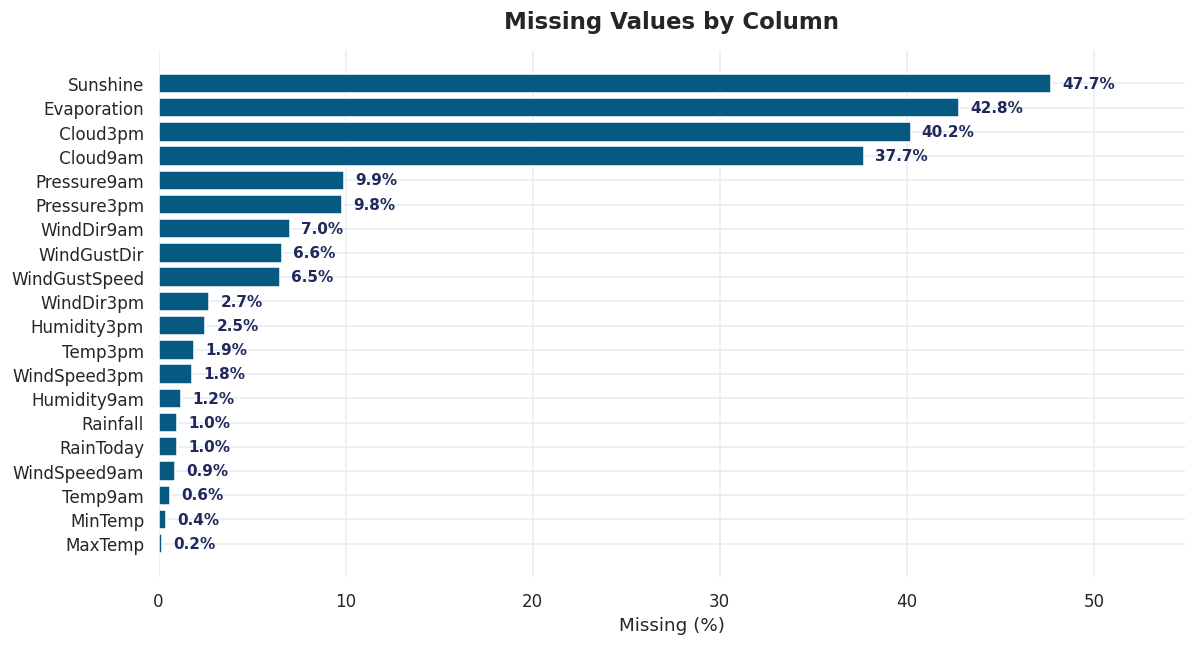

In [ ]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)

plt.figure(figsize=(11,6))
bars = plt.barh(missing_pct.index[::-1], missing_pct.values[::-1], color=PRIMARY)

for bar, pct in zip(bars, missing_pct.values[::-1]):
    plt.text(bar.get_width() + 0.6, bar.get_y() + bar.get_height()/2, f"{pct}%",
              va="center", fontsize=10, color=ACCENT, fontweight="bold")

plt.title("Missing Values by Column")
plt.xlabel("Missing (%)")
plt.xlim(0, missing_pct.max() * 1.15)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

### Note`Sunshine` (47.7%) and `Evaporation` (42.8%) have by far the highest missing rates, followed by `Cloud3pm` (40.2%) and `Cloud9am` (37.7%). `Pressure9am`/`Pressure3pm` are missing ~9.8%, and most remaining columns are below 3%. These will be handled with median (numeric) / most-frequent (categorical) imputation.

# Target Distribution

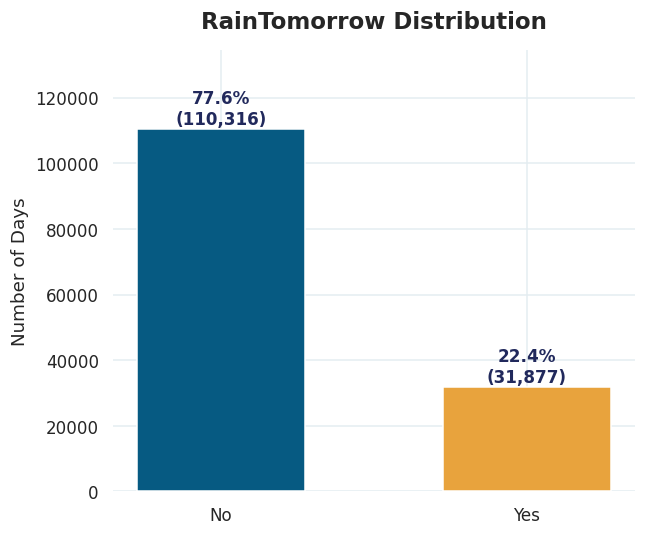

In [ ]:
counts = df["RainTomorrow"].value_counts()
pcts = df["RainTomorrow"].value_counts(normalize=True) * 100

plt.figure(figsize=(6,5))
bars = plt.bar(counts.index, counts.values,
                color=[TARGET_PALETTE[c] for c in counts.index], width=0.55)

for bar, cat in zip(bars, counts.index):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
              f"{pcts[cat]:.1f}%\n({counts[cat]:,})", ha="center", fontsize=11,
              color=ACCENT, fontweight="bold")

plt.title("RainTomorrow Distribution")
plt.ylabel("Number of Days")
plt.xlabel("")
plt.ylim(0, counts.max() * 1.22)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

In [ ]:
df["RainTomorrow"].value_counts(normalize=True) * 100

RainTomorrow
No     77.581878
Yes    22.418122
Name: proportion, dtype: float64

### Note`RainTomorrow` is moderately imbalanced: **77.6% "No"** vs **22.4% "Yes"**. This isn't severe enough to justify resampling (e.g. SMOTE), but it does mean accuracy alone would be misleading — F1-score and `class_weight="balanced"` are used to keep the minority ("Yes") class from being ignored.

# Train Test Split

In [12]:
x = df.drop("RainTomorrow", axis=1)

y = df["RainTomorrow"]

In [13]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print(x_train.shape)

print(x_test.shape)

(113754, 24)
(28439, 24)


# Feature Engineering

In [14]:
x_train["TempDifference"] = x_train["MaxTemp"] - x_train["MinTemp"]

x_test["TempDifference"] = x_test["MaxTemp"] - x_test["MinTemp"]
x_train["HumidityDifference"] = x_train["Humidity3pm"] - x_train["Humidity9am"]

x_test["HumidityDifference"] = x_test["Humidity3pm"] - x_test["Humidity9am"]
x_train["PressureDifference"] = x_train["Pressure3pm"] - x_train["Pressure9am"]

x_test["PressureDifference"] = x_test["Pressure3pm"] - x_test["Pressure9am"]
x_train["WindSpeedDifference"] = x_train["WindSpeed3pm"] - x_train["WindSpeed9am"]

x_test["WindSpeedDifference"] = x_test["WindSpeed3pm"] - x_test["WindSpeed9am"]

### NoteFour difference features were added — TempDifference, HumidityDifference, PressureDifference, and WindSpeedDifference — each capturing how much a measurement changed between 9am and 3pm. These are computed independently on the training and test sets (after the split) to avoid data leakage.

# Feature Types

In [15]:
numerical_columns = x_train.select_dtypes(
    include=["int64","float64"]
).columns.tolist()

categorical_columns = x_train.select_dtypes(
    include="object"
).columns.tolist()

# Missing Value Imputation

In [16]:
num_imputer = SimpleImputer(
    strategy="median"
)

cat_imputer = SimpleImputer(
    strategy="most_frequent"
)

In [17]:
x_train[numerical_columns] = num_imputer.fit_transform(
    x_train[numerical_columns]
)

x_test[numerical_columns] = num_imputer.transform(
    x_test[numerical_columns]
)

In [18]:
x_train[categorical_columns] = cat_imputer.fit_transform(
    x_train[categorical_columns]
)

x_test[categorical_columns] = cat_imputer.transform(
    x_test[categorical_columns]
)

In [ ]:
print(x_train.isnull().sum().sum())

print(x_test.isnull().sum().sum())

0
0


# Outliers handling

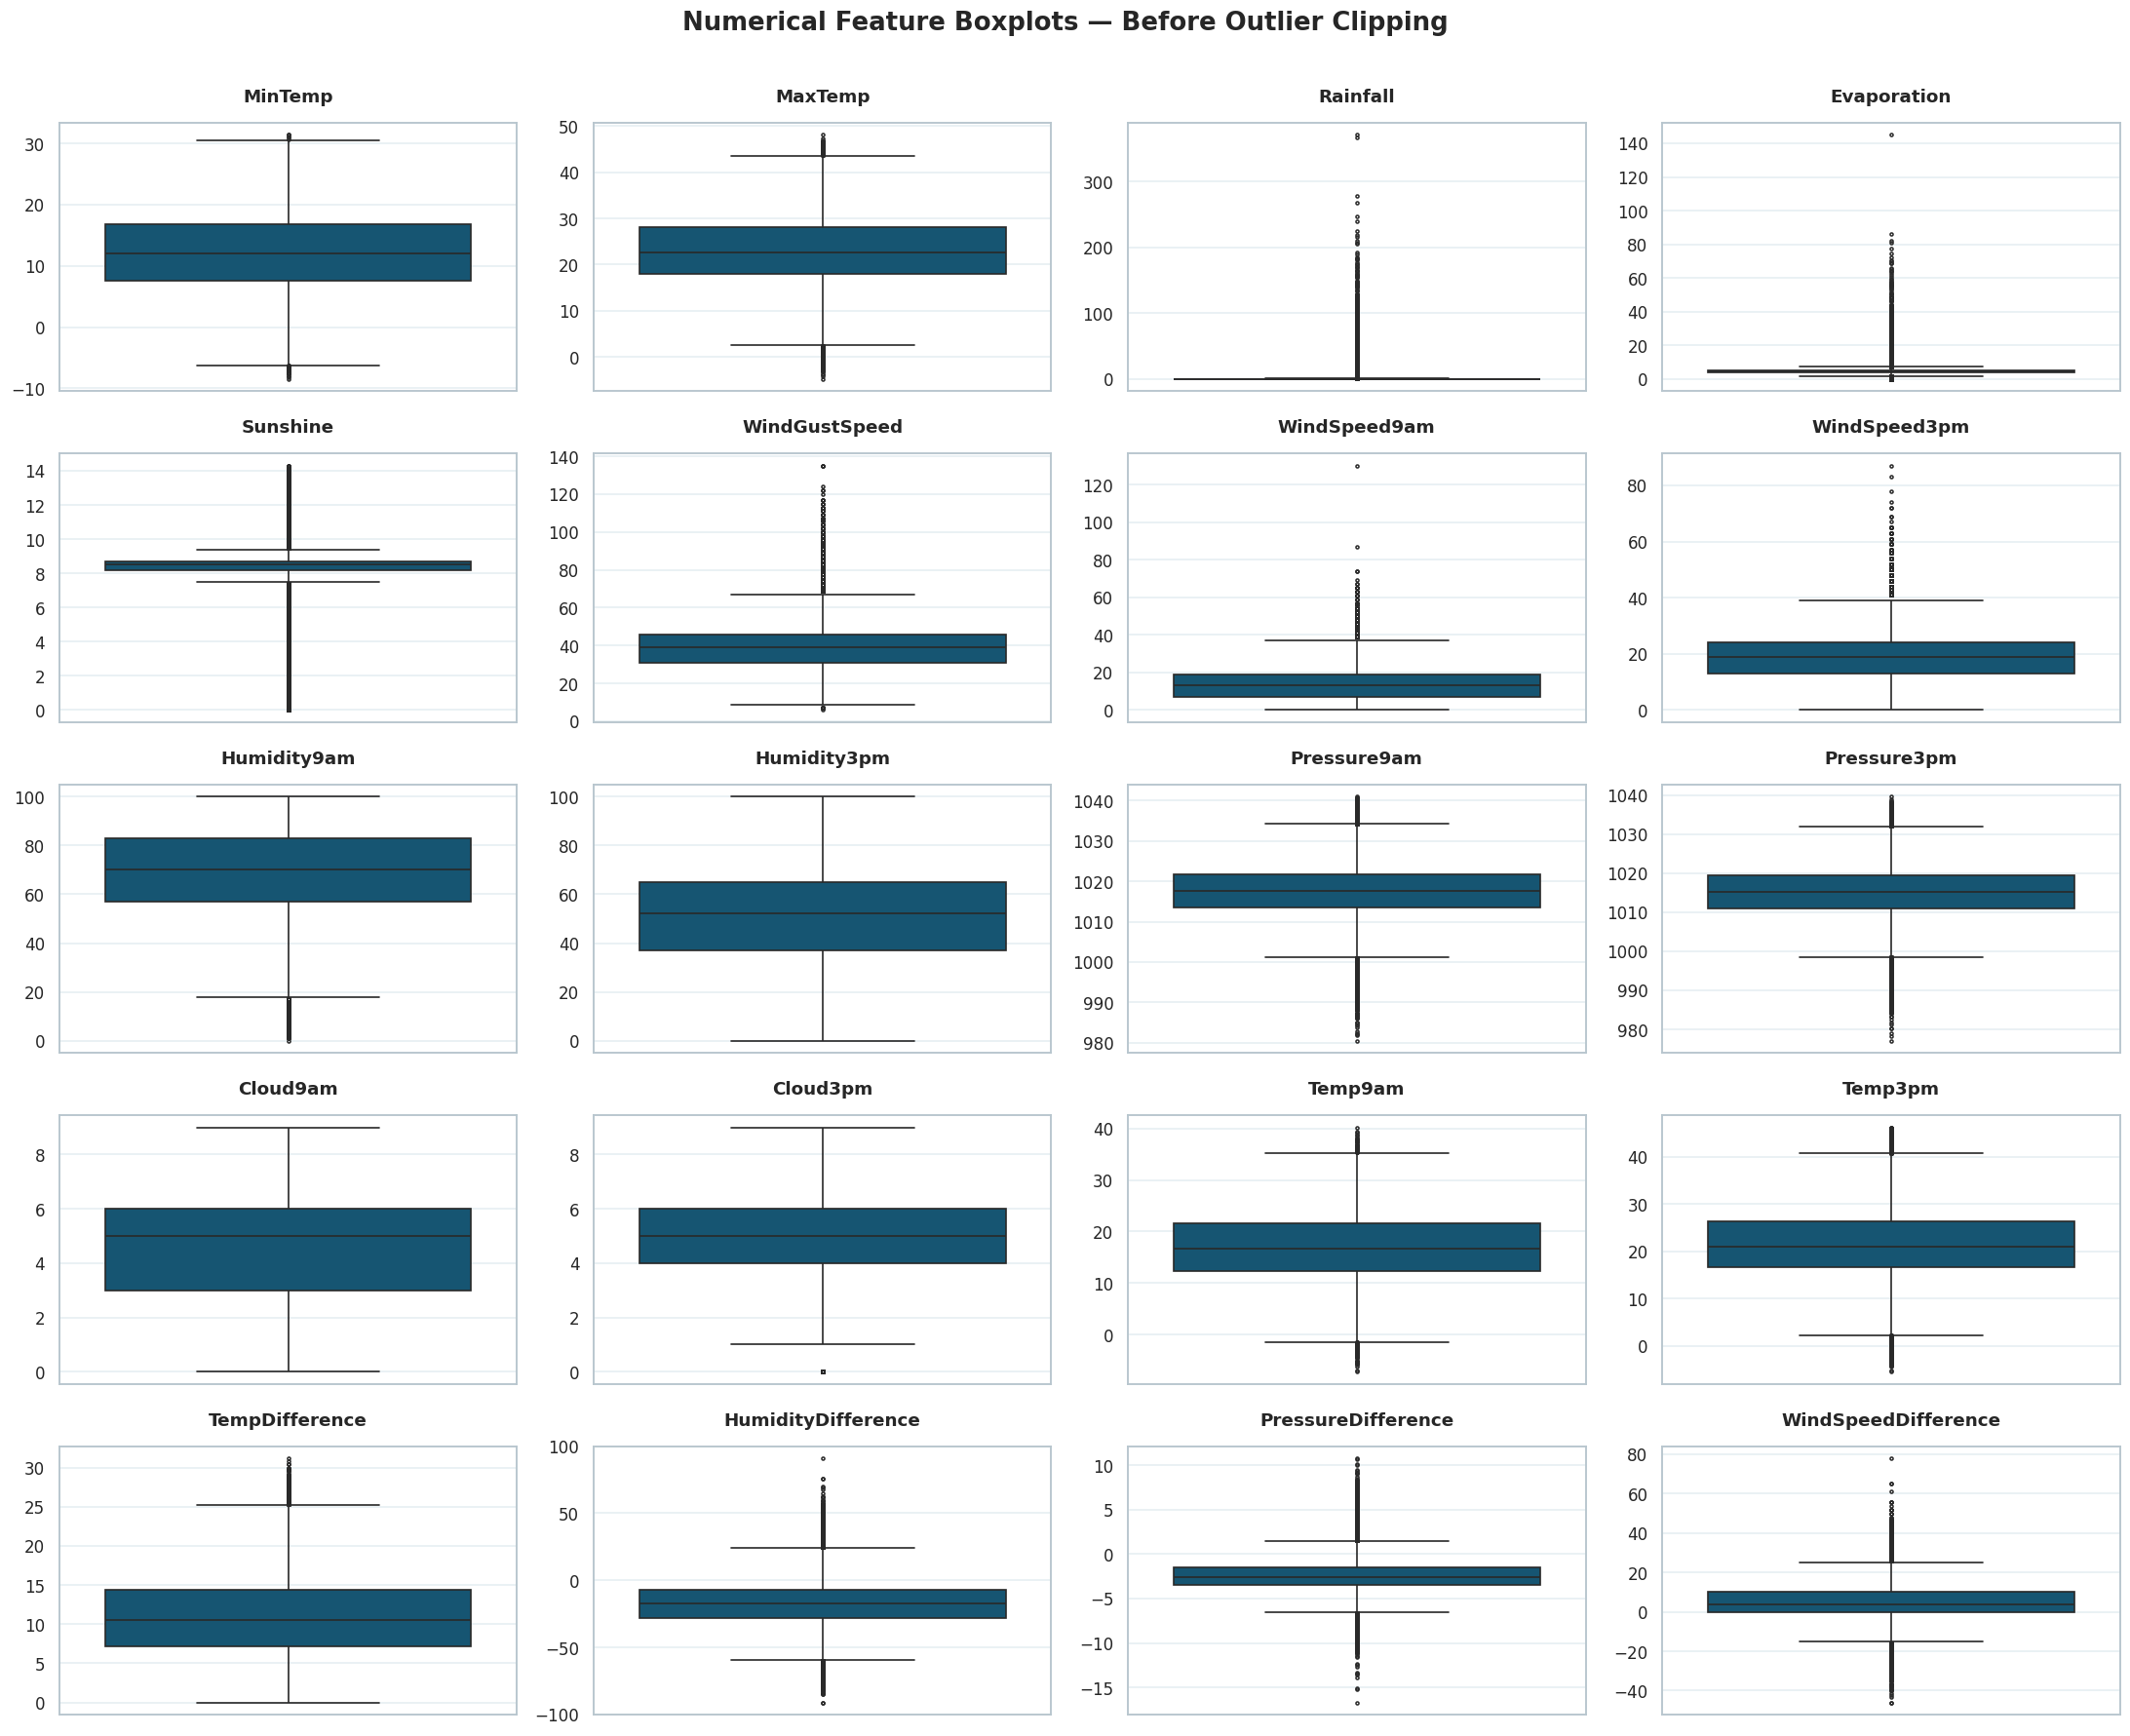

In [19]:
plt.figure(figsize=(20,16))

for i, column in enumerate(numerical_columns):
    plt.subplot(5,4,i+1)
    sns.boxplot(y=x_train[column], color=PRIMARY, fliersize=2, linewidth=1.1)
    plt.title(column, fontsize=12)
    plt.ylabel("")

plt.suptitle("Numerical Feature Boxplots — Before Outlier Clipping", fontsize=17, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [20]:
for column in numerical_columns:

    Q1 = x_train[column].quantile(0.25)

    Q3 = x_train[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    x_train[column] = x_train[column].clip(lower, upper)

    x_test[column] = x_test[column].clip(lower, upper)

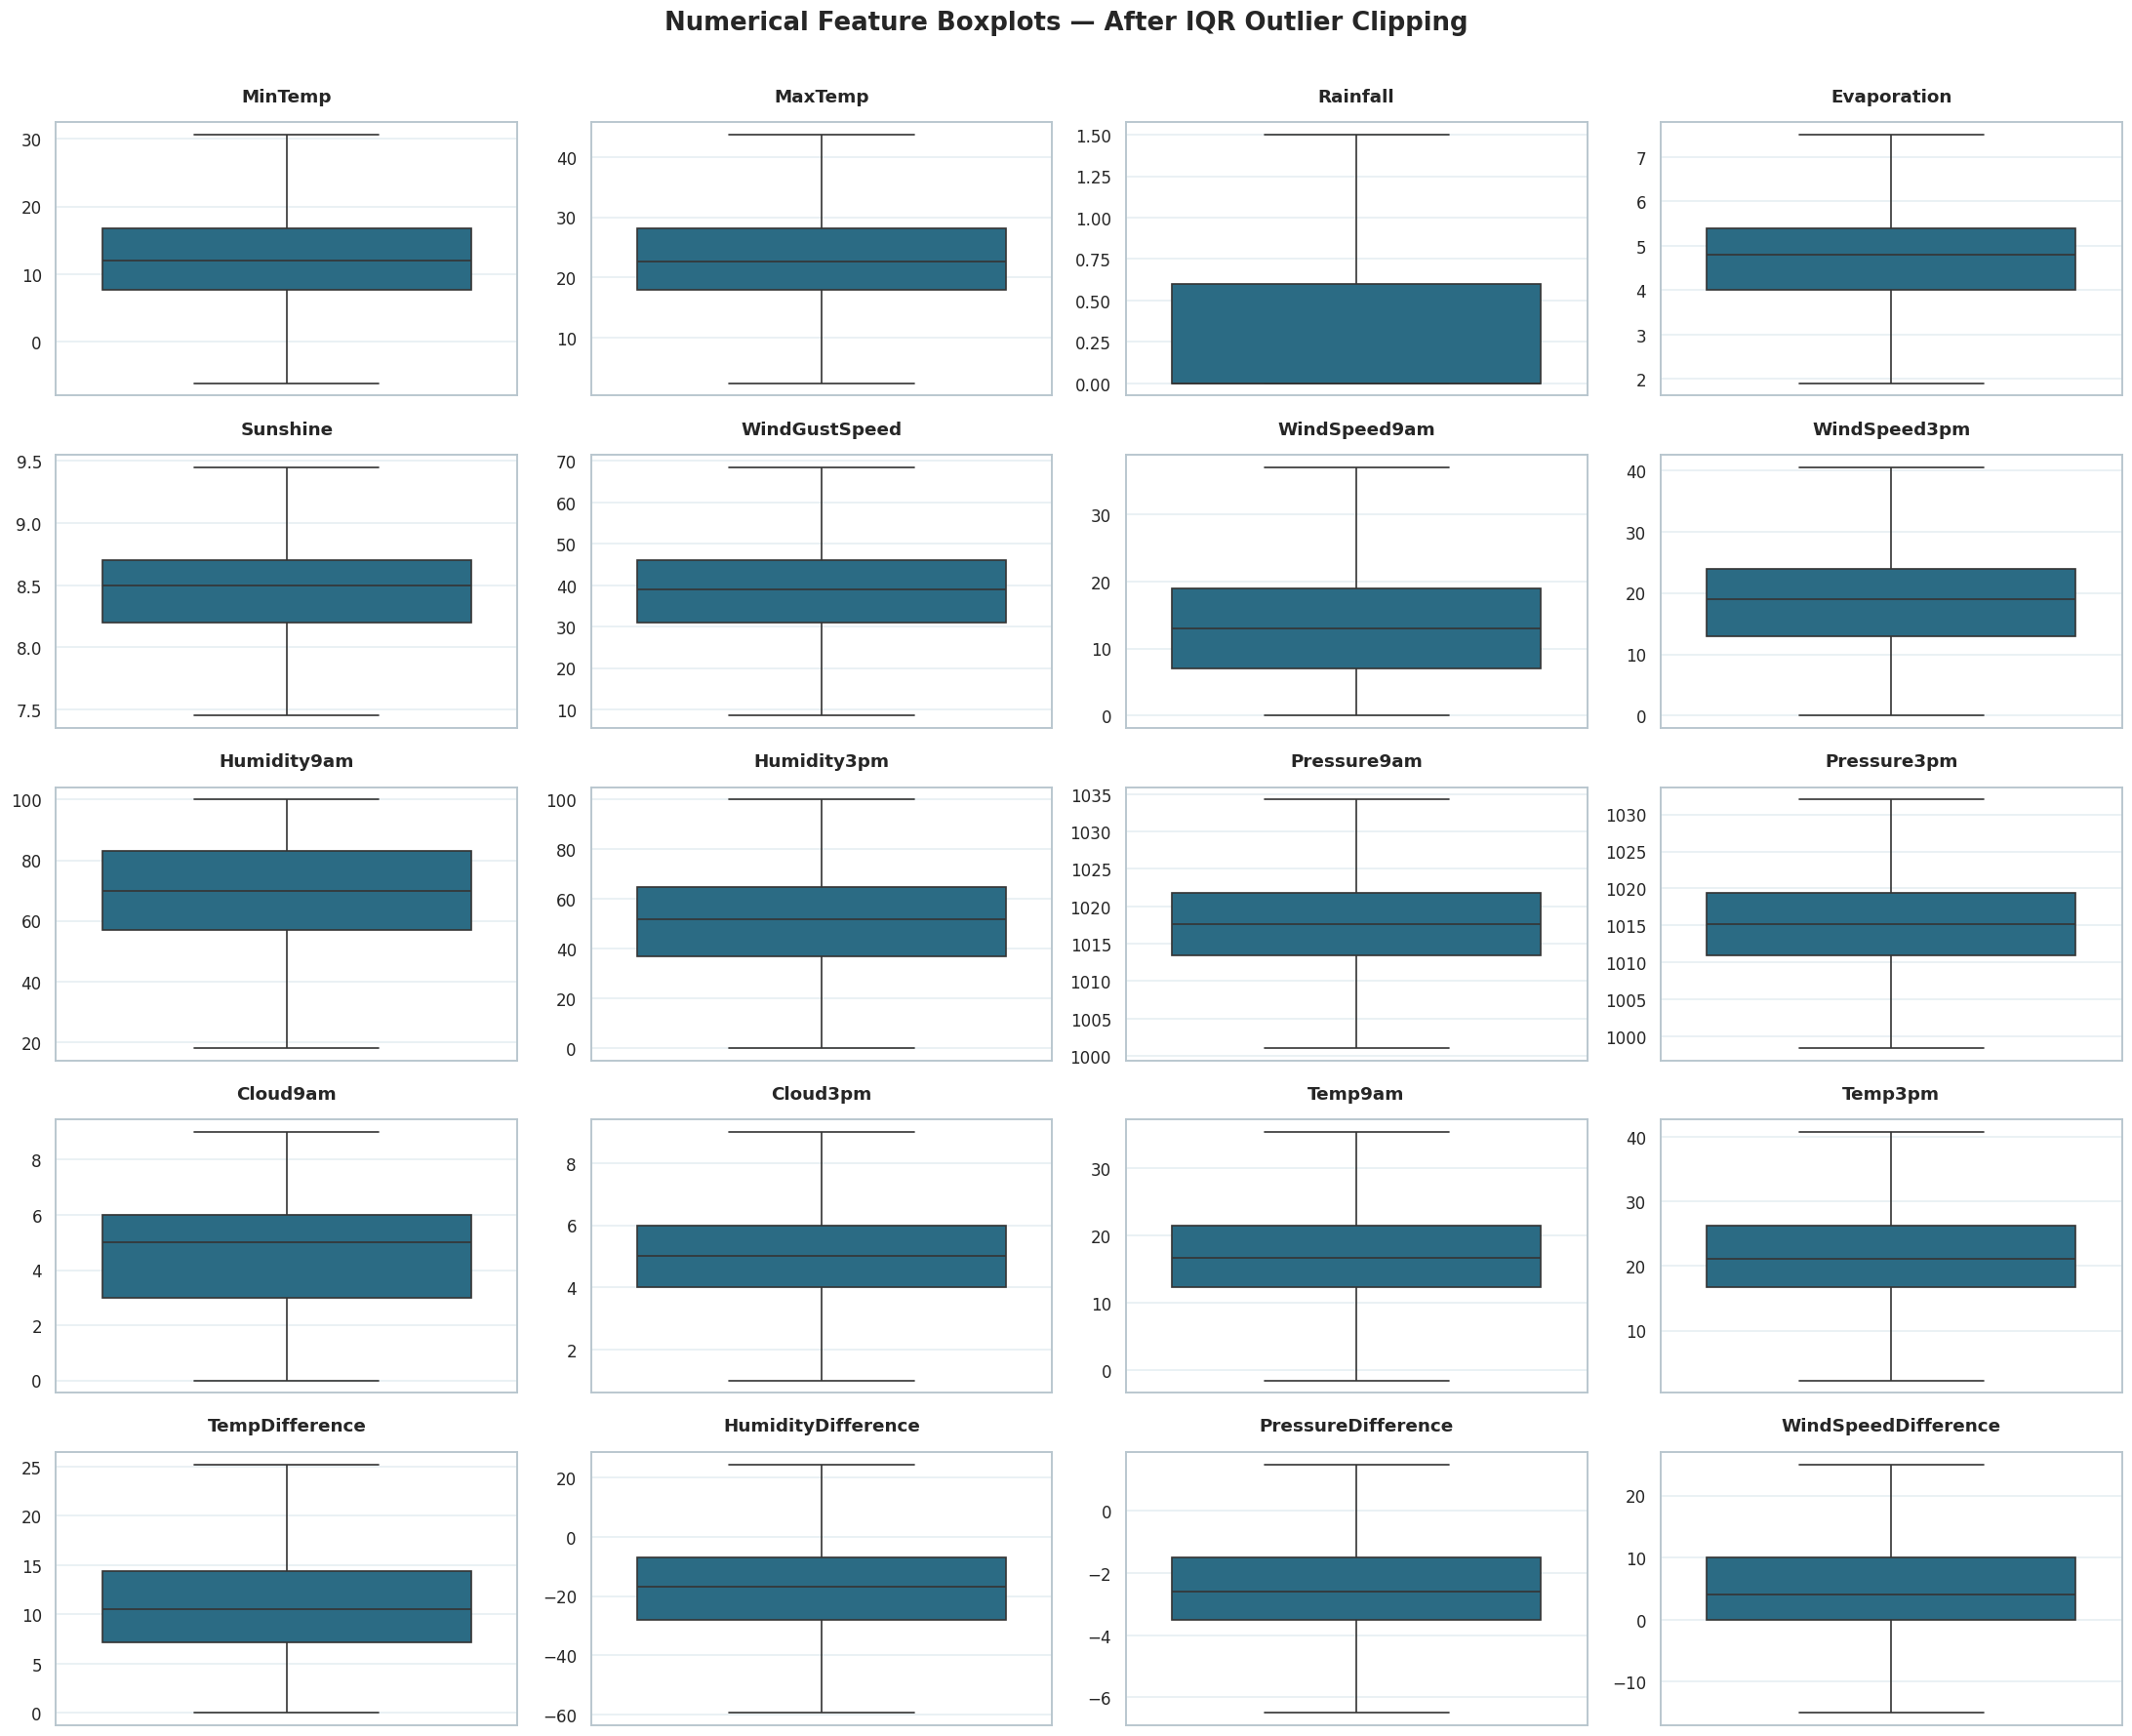

In [21]:
plt.figure(figsize=(20,16))

for i, column in enumerate(numerical_columns):
    plt.subplot(5,4,i+1)
    sns.boxplot(y=x_train[column], color=SECONDARY, fliersize=2, linewidth=1.1)
    plt.title(column, fontsize=12)
    plt.ylabel("")

plt.suptitle("Numerical Feature Boxplots — After IQR Outlier Clipping", fontsize=17, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### NoteBounds were computed from the training set only (1.5×IQR beyond Q1/Q3) and applied to both the training and test sets. `Sunshine`, `Evaporation`, and `Rainfall` had the highest share of values flagged as outliers (over 20% each) — expected for Rainfall and Evaporation, which are naturally right-skewed with many near-zero days. For `Sunshine`, this shows the standard IQR rule is a blunt instrument on a bounded, left-skewed variable; the flagged "outliers" are mostly ordinary high-sunshine days rather than true anomalies.

# Feature Distribution

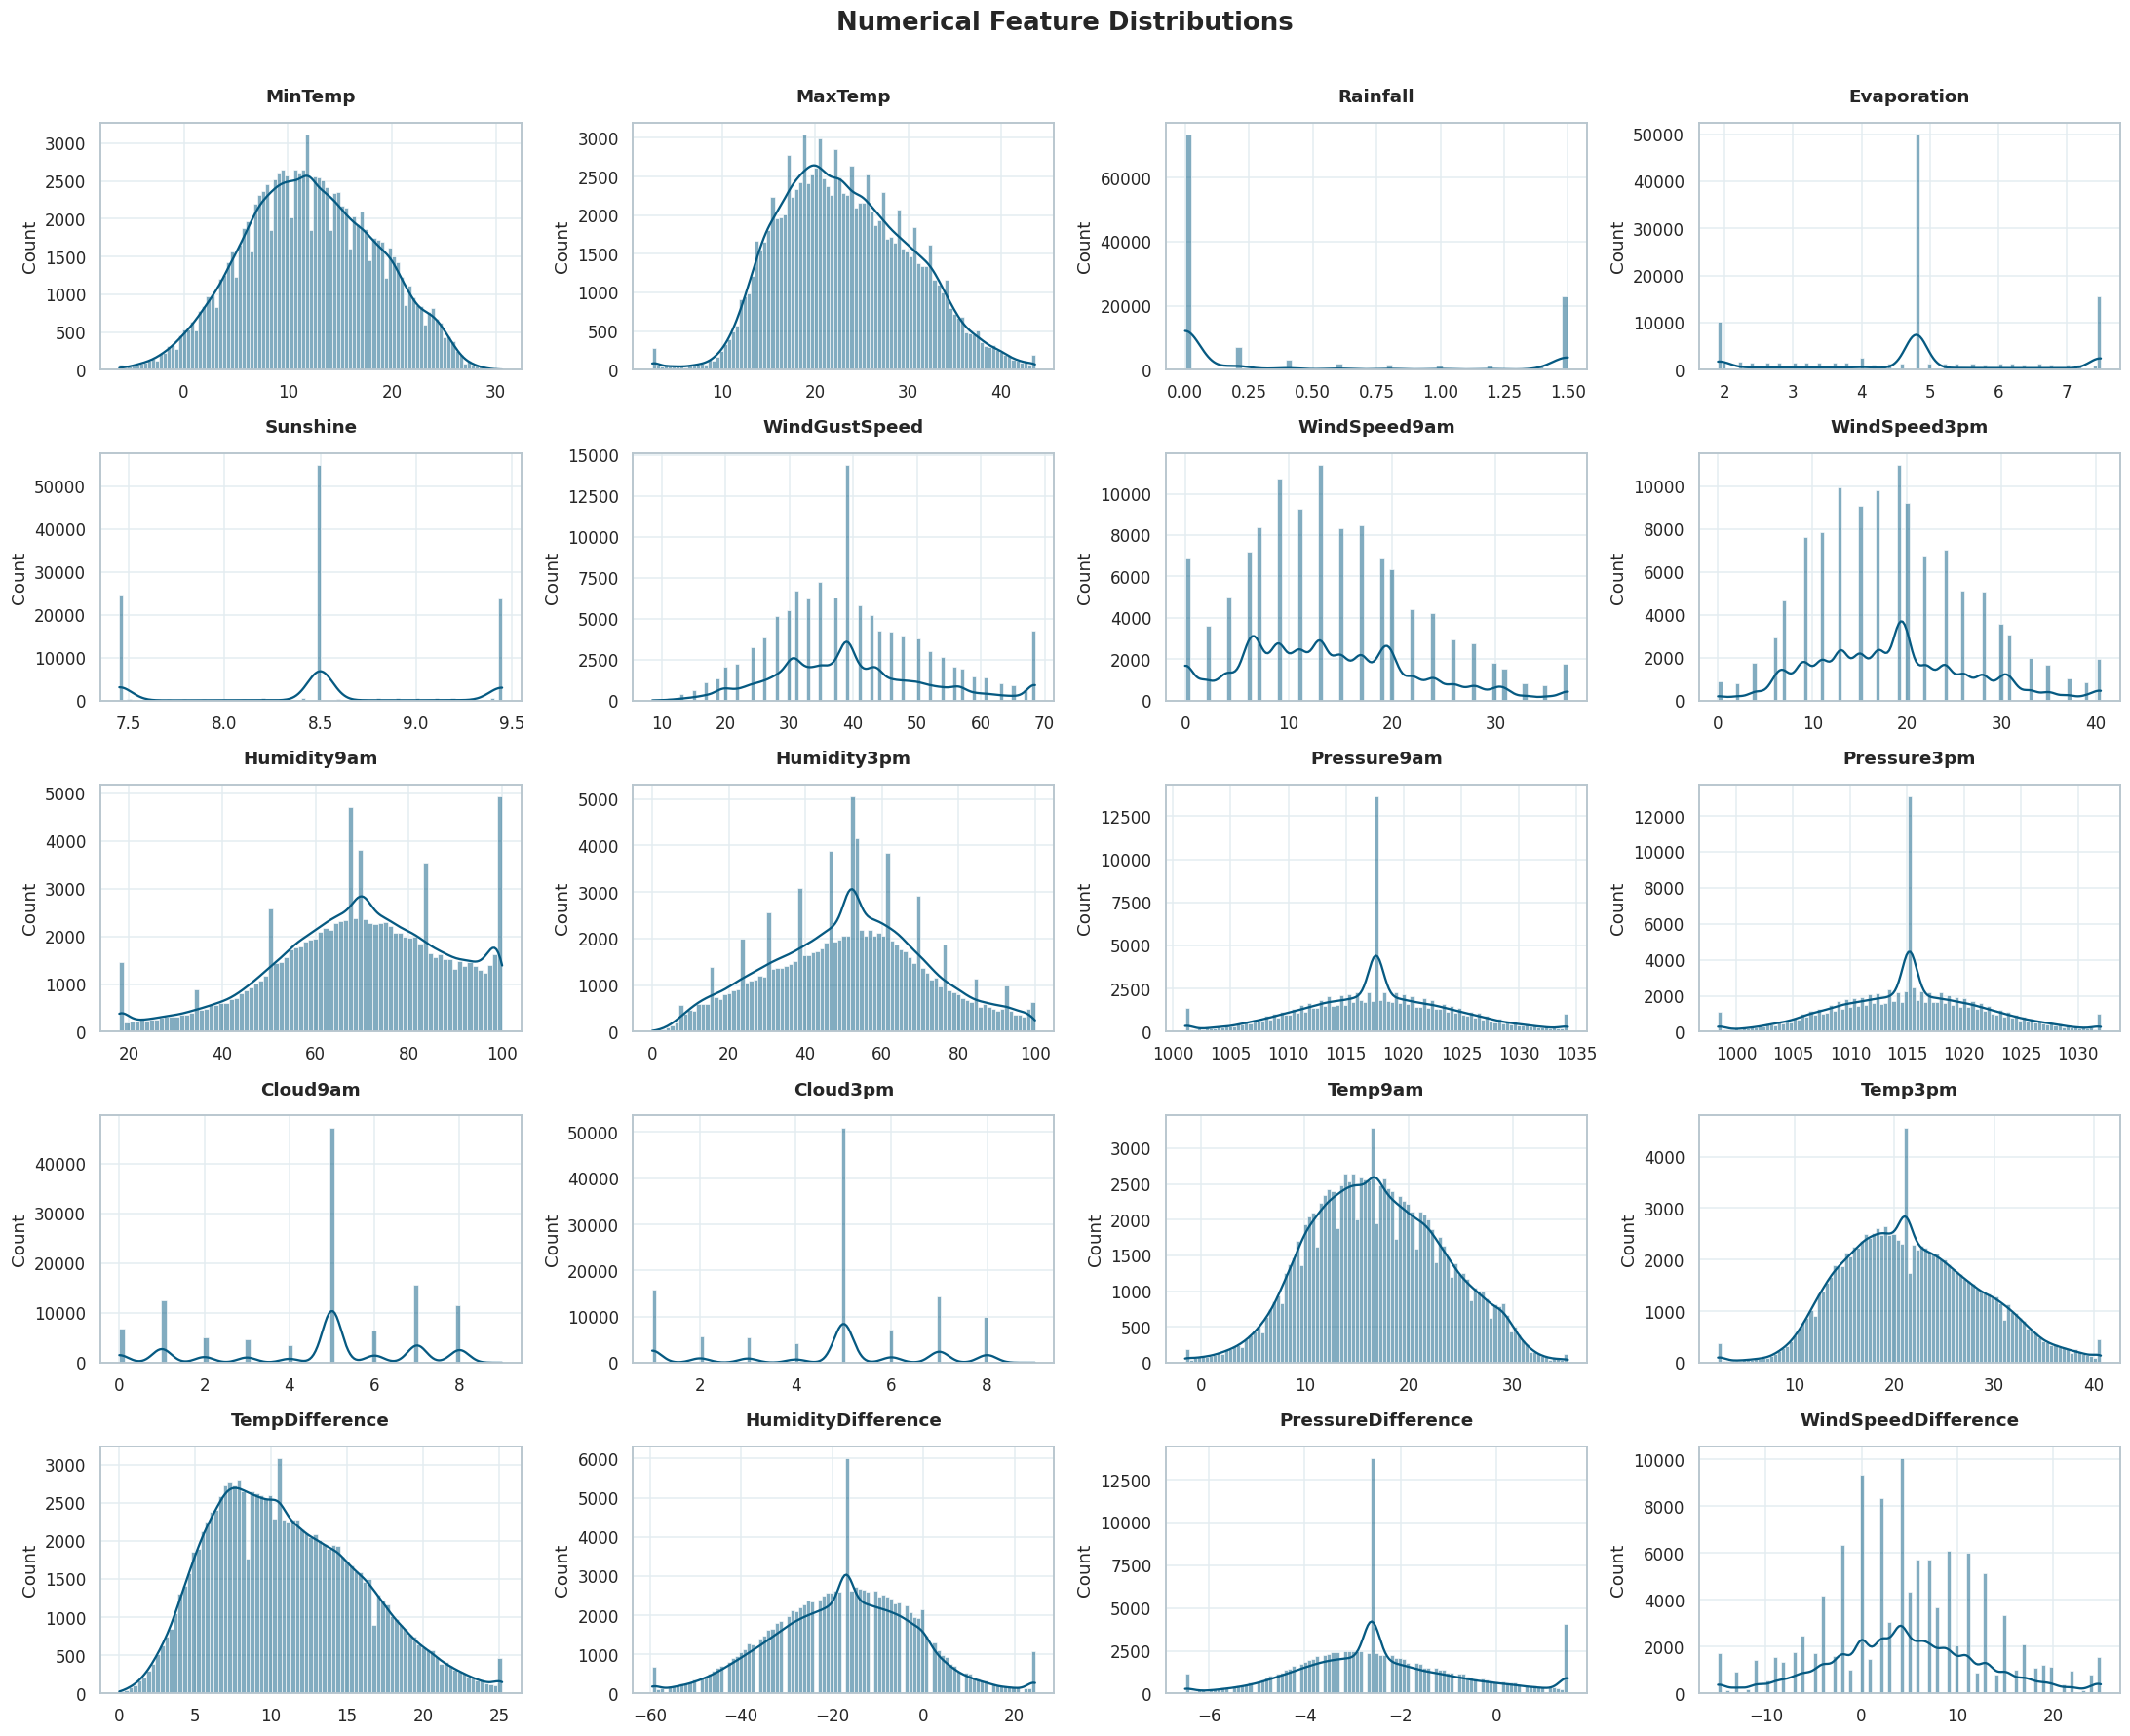

In [ ]:
plt.figure(figsize=(20,16))

for i, column in enumerate(numerical_columns):
    plt.subplot(5,4,i+1)
    sns.histplot(x=x_train[column], color=PRIMARY, kde=True, edgecolor="white", linewidth=0.4)
    plt.title(column, fontsize=12)
    plt.xlabel("")

plt.suptitle("Numerical Feature Distributions", fontsize=17, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### Note`Rainfall` and `Evaporation` are the most heavily right-skewed features (most days near zero, with a long tail of extreme values), while `Sunshine`, `Cloud9am`, and `Cloud3pm` lean left-skewed (clustered toward their upper range). `Pressure9am` is close to symmetric. This skew is typical for weather data and is one reason `StandardScaler` — rather than an assumption of normality — is used during preprocessing.

# Categorical Feature Distribution

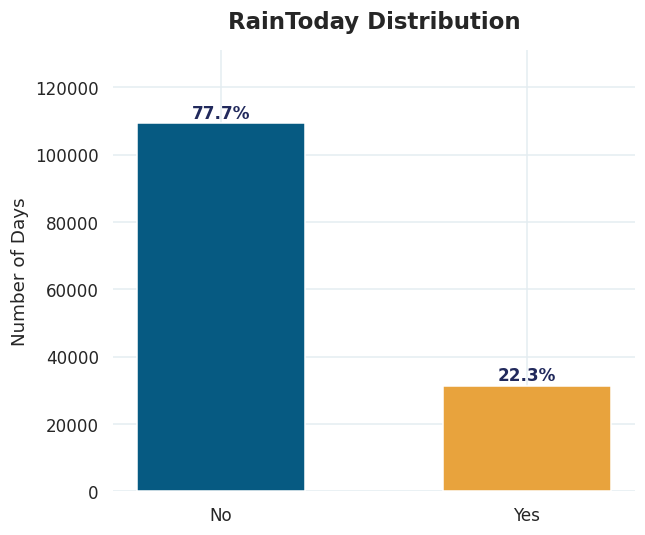

In [ ]:
counts = df["RainToday"].value_counts().reindex(["No","Yes"])
pcts = (counts / counts.sum() * 100)

plt.figure(figsize=(6,5))
bars = plt.bar(counts.index, counts.values,
                color=[TARGET_PALETTE[c] for c in counts.index], width=0.55)

for bar, cat in zip(bars, counts.index):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
              f"{pcts[cat]:.1f}%", ha="center", fontsize=11, color=ACCENT, fontweight="bold")

plt.title("RainToday Distribution")
plt.ylabel("Number of Days")
plt.xlabel("")
plt.ylim(0, counts.max() * 1.2)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

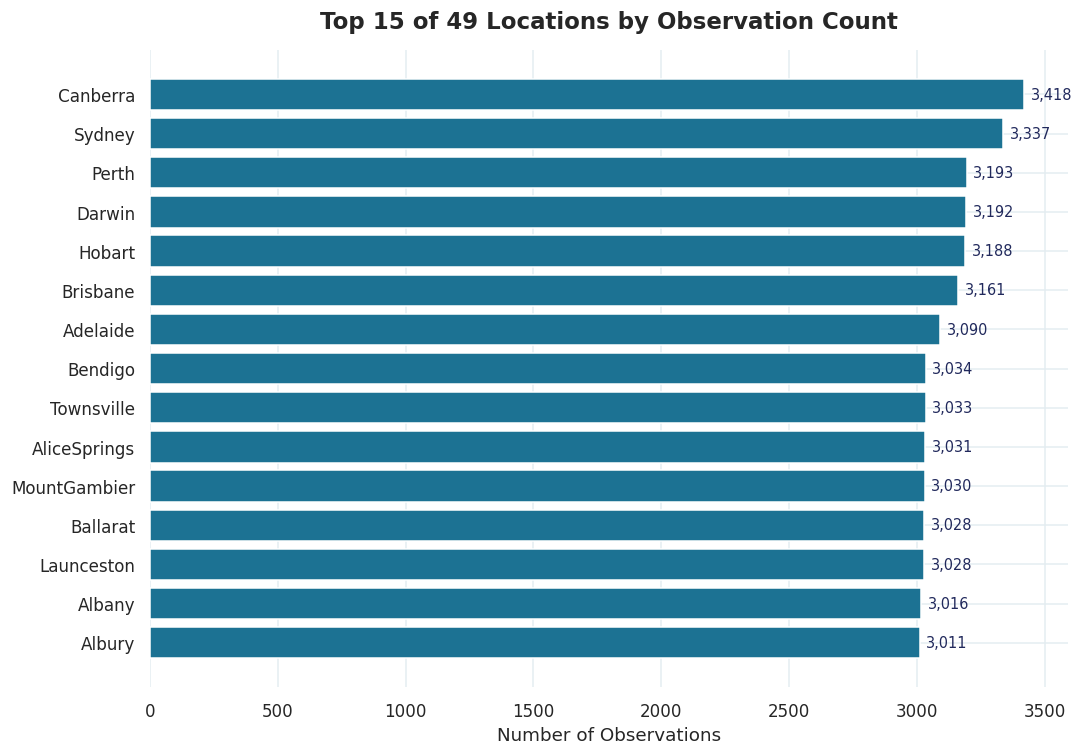

In [ ]:
top_locations = df["Location"].value_counts().head(15)

plt.figure(figsize=(10,7))
bars = plt.barh(top_locations.index[::-1], top_locations.values[::-1], color=SECONDARY)

for bar, val in zip(bars, top_locations.values[::-1]):
    plt.text(bar.get_width() + 25, bar.get_y() + bar.get_height()/2, f"{val:,}",
              va="center", fontsize=9.5, color=ACCENT)

plt.title(f"Top 15 of {df['Location'].nunique()} Locations by Observation Count")
plt.xlabel("Number of Observations")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

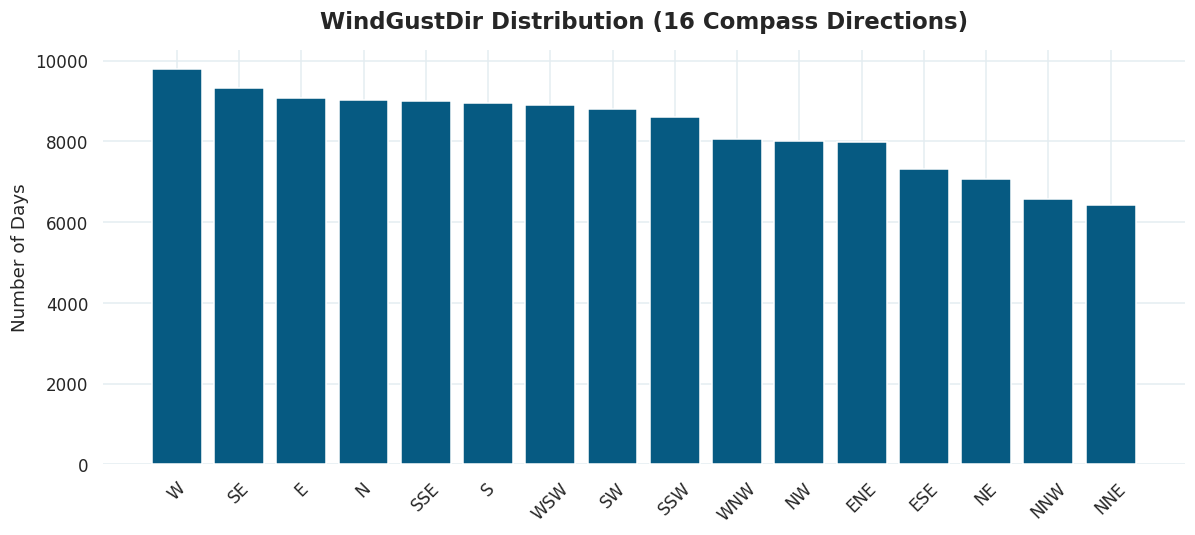

In [ ]:
wind_counts = df["WindGustDir"].value_counts()

plt.figure(figsize=(11,5))
bars = plt.bar(wind_counts.index, wind_counts.values, color=PRIMARY)

plt.title("WindGustDir Distribution (16 Compass Directions)")
plt.ylabel("Number of Days")
plt.xlabel("")
plt.xticks(rotation=45)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

### Note`RainToday` mirrors the target's imbalance almost exactly (77.7% No / 22.3% Yes), which makes sense since both are derived from the same rainfall threshold on consecutive days. Station coverage is fairly even across `Location` (49 stations, each with roughly 3,000-3,400 observations), so no single station dominates the dataset. `WindGustDir` is close to uniformly distributed across the 16 compass directions, with a slight lean toward W, SE and E.

# Correlation Analysis

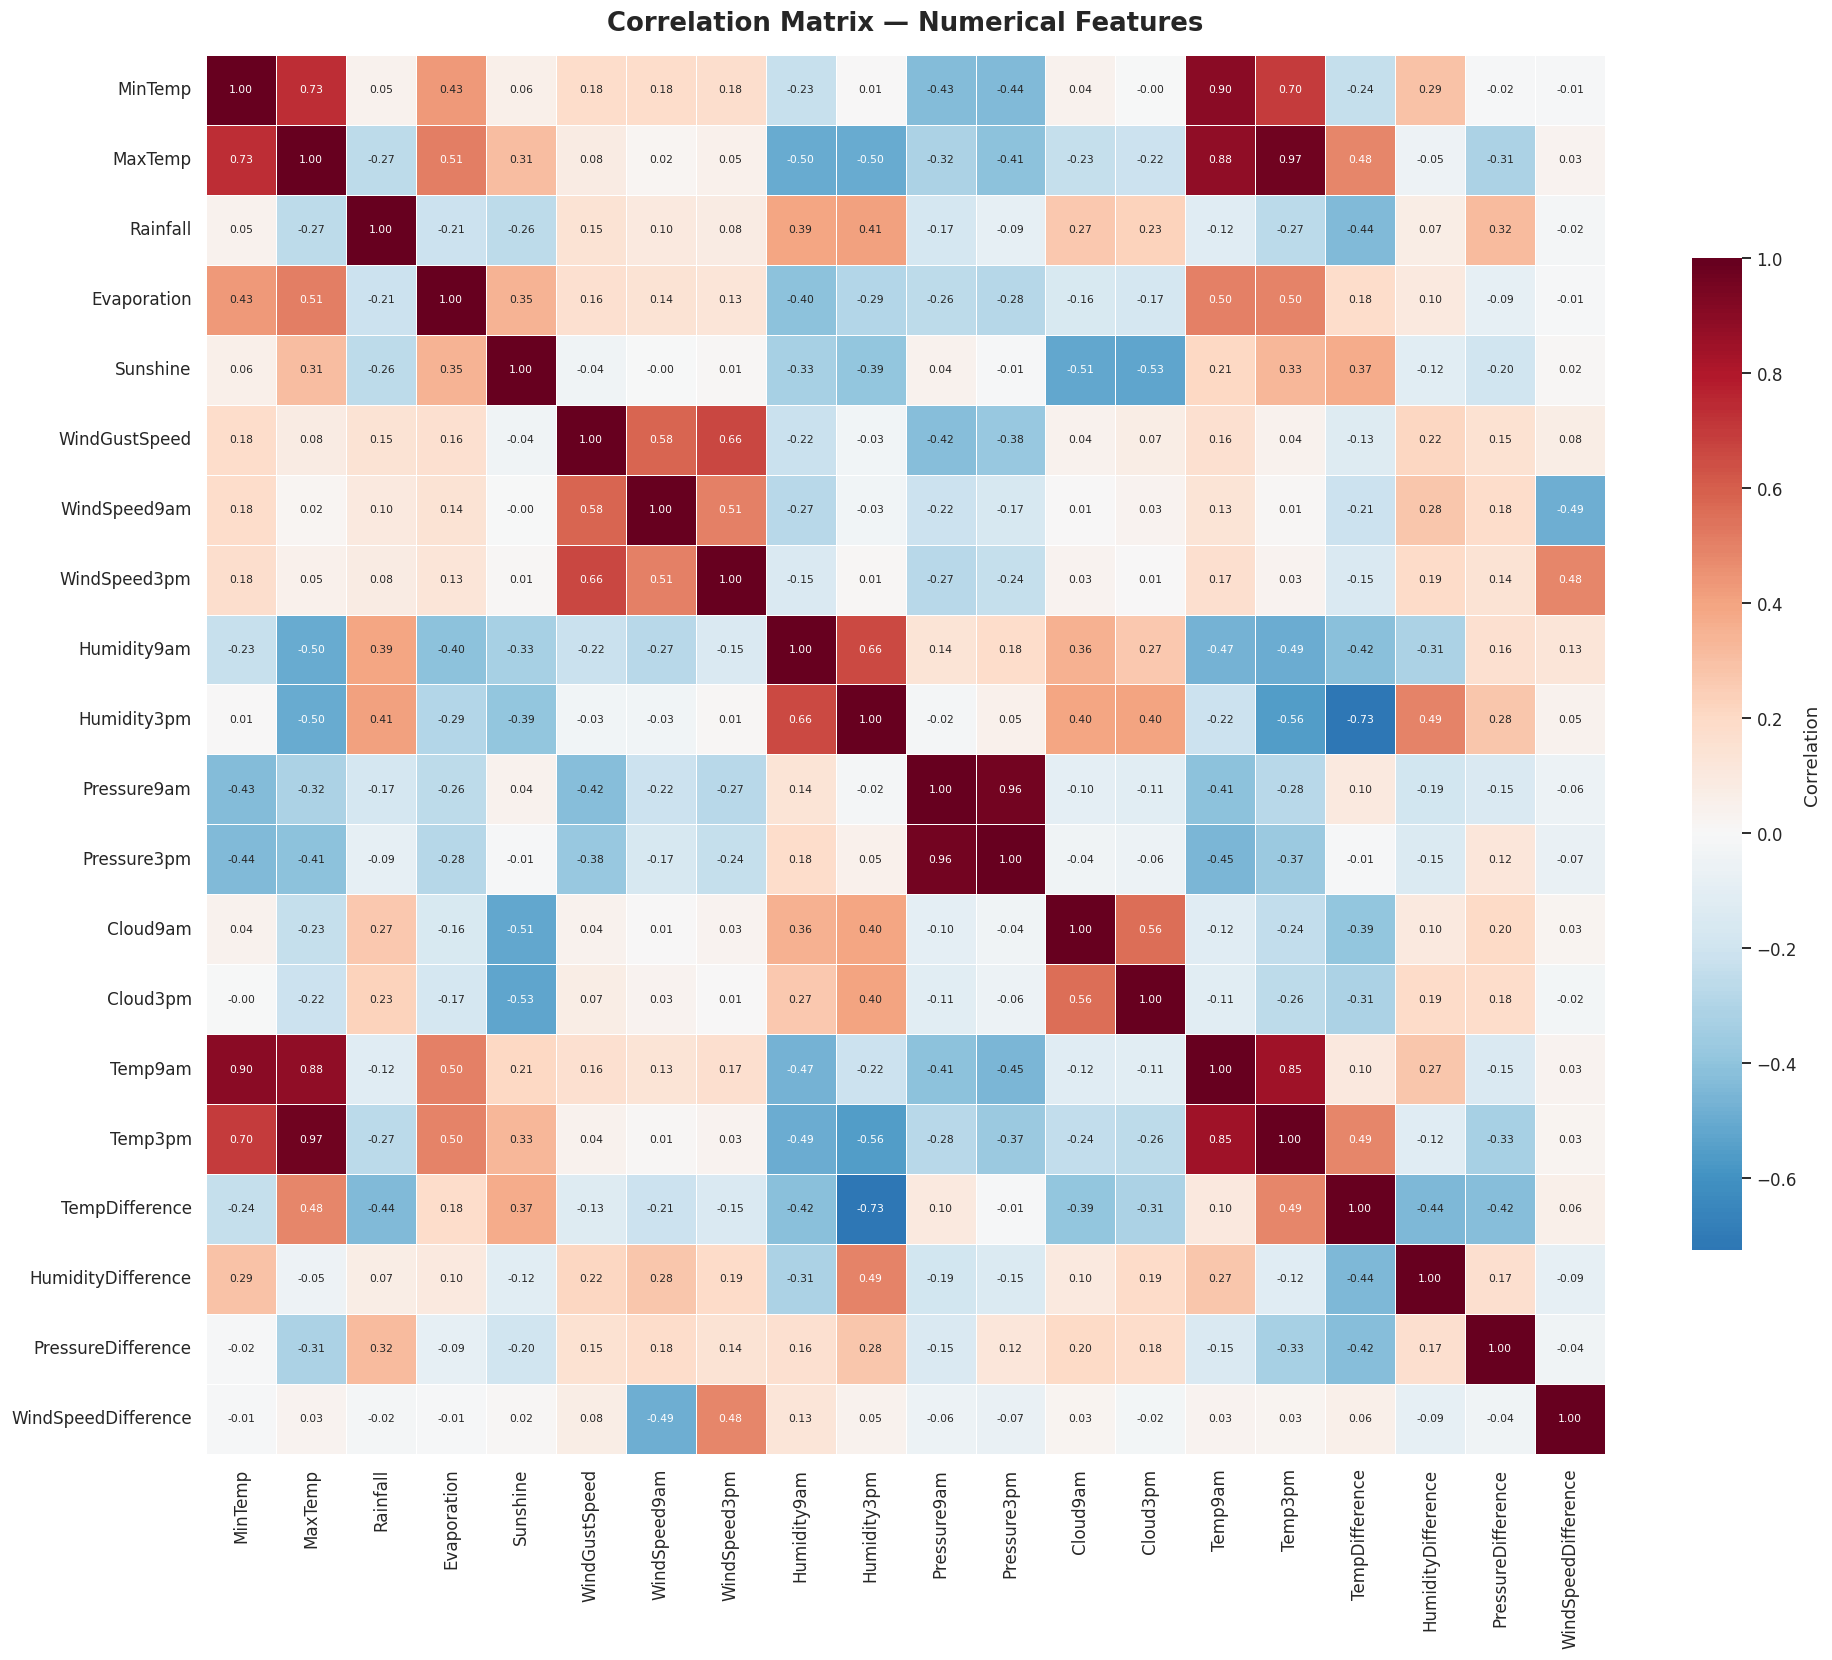

In [25]:
plt.figure(figsize=(18,15))

corr = x_train[numerical_columns].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7},
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"shrink": 0.7, "label": "Correlation"}
)

plt.title("Correlation Matrix — Numerical Features", fontsize=17, pad=16)
plt.tight_layout()
plt.show()

### NoteThe strongest correlations are between same-quantity measurements taken at different times: `MaxTemp` vs `Temp3pm` (0.98), `Pressure9am` vs `Pressure3pm` (0.96), and `MinTemp` vs `Temp9am` (0.90). `Sunshine` is strongly negatively correlated with `Cloud3pm`/`Cloud9am` (~-0.70), which matches physical intuition (more cloud cover, less sunshine). This multicollinearity is expected for weather data and is handled naturally by the tree-based models; it isn't a concern for the linear models here since none of the correlated pairs are perfectly collinear.

# Data Preprocessing

In [ ]:
numeric_transformer = Pipeline([
    (
        "scaler",
        StandardScaler()
    )
])

categorical_transformer = Pipeline([
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_columns
        ),
        (
            "cat",
            categorical_transformer,
            categorical_columns
        )
    ]
)

In [ ]:
print(categorical_columns)

['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']


# Model Evaluation Function

In [ ]:
results = []

In [ ]:
def evaluate_model(name, model, x_test, y_test):

    y_pred = model.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        pos_label="Yes"
    )

    recall = recall_score(
        y_test,
        y_pred,
        pos_label="Yes"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        pos_label="Yes"
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    print(f"{name} Finished")

    return y_pred

# Logistic Regression

In [ ]:
logistic_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        LogisticRegression(
            random_state=42,
            max_iter=1000,
            class_weight="balanced"
        )
    )
])

In [ ]:
logistic_pipeline.fit(
    x_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [ ]:
logistic_pred = evaluate_model(
    "Logistic Regression",
    logistic_pipeline,
    x_test,
    y_test
)

Logistic Regression Finished


# Naive Bayes

In [ ]:
naive_bayes_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        GaussianNB()
    )
])

In [ ]:
naive_bayes_pipeline.fit(
    x_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [ ]:
naive_bayes_pred = evaluate_model(
    "Naive Bayes",
    naive_bayes_pipeline,
    x_test,
    y_test
)

Naive Bayes Finished


# K-Nearest Neighbours

In [ ]:
knn_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        KNeighborsClassifier()
    )
])

In [ ]:
knn_pipeline.fit(
    x_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [ ]:
knn_pred = evaluate_model(
    "KNN",
    knn_pipeline,
    x_test,
    y_test
)

KNN Finished


In [ ]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.795914,0.530043,0.790118,0.634463
1,Naive Bayes,0.657196,0.367769,0.736000,0.490462
2,KNN,0.841837,0.704155,0.507765,0.590047


# Decision Tree

In [ ]:
decision_tree_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        DecisionTreeClassifier(
            random_state=42,
            class_weight="balanced"
        )
    )
])

In [ ]:
decision_tree_pipeline.fit(
    x_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [ ]:
decision_tree_pred = evaluate_model(
    "Decision Tree",
    decision_tree_pipeline,
    x_test,
    y_test
)

Decision Tree Finished


# Random Forest

In [ ]:
random_forest_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        RandomForestClassifier(
            random_state=42,
            class_weight="balanced"
        )
    )
])

In [ ]:
random_forest_pipeline.fit(
    x_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [ ]:
random_forest_pred = evaluate_model(
    "Random Forest",
    random_forest_pipeline,
    x_test,
    y_test
)

Random Forest Finished


# Extra Trees

In [ ]:
extra_trees_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        ExtraTreesClassifier(
            random_state=42,
            class_weight="balanced"
        )
    )
])

In [ ]:
extra_trees_pipeline.fit(
    x_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [ ]:
extra_trees_pred = evaluate_model(
    "Extra Trees",
    extra_trees_pipeline,
    x_test,
    y_test
)

Extra Trees Finished


# SVC

In [ ]:
svc_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        LinearSVC(
            random_state=42,
            class_weight="balanced",
            max_iter=5000
        )
    )
])

In [ ]:
svc_pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [ ]:
svc_pred = evaluate_model(
    "SVC",
    svc_pipeline,
    x_test,
    y_test
)

SVC Finished


# Bagging

In [ ]:
bagging_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        BaggingClassifier(
            random_state=42
        )
    )
])

In [ ]:
bagging_pipeline.fit(
    x_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [ ]:
bagging_pred = evaluate_model(
    "Bagging",
    bagging_pipeline,
    x_test,
    y_test
)

Bagging Finished


In [ ]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.795914,0.530043,0.790118,0.634463
1,Naive Bayes,0.657196,0.367769,0.736000,0.490462
2,KNN,0.841837,0.704155,0.507765,0.590047
3,Decision Tree,0.791097,0.534532,0.526902,0.530690
4,Random Forest,0.852737,0.781322,0.476392,0.591892
5,Extra Trees,0.855269,0.788506,0.484235,0.600000
6,SVC,0.796828,0.531631,0.786980,0.634581
7,Bagging,0.842364,0.723113,0.480941,0.577673


# AdaBoost

In [ ]:
adaboost_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        AdaBoostClassifier(
            random_state=42
        )
    )
])

In [ ]:
adaboost_pipeline.fit(
    x_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [ ]:
adaboost_pred = evaluate_model(
    "AdaBoost",
    adaboost_pipeline,
    x_test,
    y_test
)

AdaBoost Finished


# Gradient Boosting

In [ ]:
gradient_boosting_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        GradientBoostingClassifier(
            random_state=42
        )
    )
])

In [ ]:
gradient_boosting_pipeline.fit(
    x_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [ ]:
gradient_boosting_pred = evaluate_model(
    "Gradient Boosting",
    gradient_boosting_pipeline,
    x_test,
    y_test
)

Gradient Boosting Finished


# Hist Gradient Boosting

In [ ]:
y_train_encoded = y_train.map(
    {
        "No":0,
        "Yes":1
    }
)

y_test_encoded = y_test.map(
    {
        "No":0,
        "Yes":1
    }
)

In [ ]:
hist_gradient_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        HistGradientBoostingClassifier(
            random_state=42
        )
    )
])

In [ ]:
hist_gradient_pipeline.fit(
    x_train,
    y_train_encoded
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [ ]:
hist_gradient_pred = hist_gradient_pipeline.predict(
    x_test
)

hist_gradient_pred = np.where(
    hist_gradient_pred==1,
    "Yes",
    "No"
)

results.append({
    "Model":"Hist Gradient Boosting",
    "Accuracy":accuracy_score(y_test,hist_gradient_pred),
    "Precision":precision_score(y_test,hist_gradient_pred,pos_label="Yes"),
    "Recall":recall_score(y_test,hist_gradient_pred,pos_label="Yes"),
    "F1 Score":f1_score(y_test,hist_gradient_pred,pos_label="Yes")
})

print("Hist Gradient Boosting Finished")

Hist Gradient Boosting Finished


In [ ]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.795914,0.530043,0.790118,0.634463
1,Naive Bayes,0.657196,0.367769,0.736000,0.490462
2,KNN,0.841837,0.704155,0.507765,0.590047
3,Decision Tree,0.791097,0.534532,0.526902,0.530690
4,Random Forest,0.852737,0.781322,0.476392,0.591892
5,Extra Trees,0.855269,0.788506,0.484235,0.600000
6,SVC,0.796828,0.531631,0.786980,0.634581
7,Bagging,0.842364,0.723113,0.480941,0.577673
8,AdaBoost,0.841063,0.718389,0.478588,0.574468
9,Gradient Boosting,0.851331,0.754928,0.498667,0.600605


# XGBoost

In [ ]:
xgboost_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        )
    )
])

In [ ]:
xgboost_pipeline.fit(
    x_train,
    y_train_encoded
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [ ]:
xgboost_pred = xgboost_pipeline.predict(
    x_test
)

xgboost_pred = np.where(
    xgboost_pred==1,
    "Yes",
    "No"
)

results.append({
    "Model":"XGBoost",
    "Accuracy":accuracy_score(y_test,xgboost_pred),
    "Precision":precision_score(y_test,xgboost_pred,pos_label="Yes"),
    "Recall":recall_score(y_test,xgboost_pred,pos_label="Yes"),
    "F1 Score":f1_score(y_test,xgboost_pred,pos_label="Yes")
})

print("XGBoost Finished")

XGBoost Finished


# LightGBM

In [ ]:
lightgbm_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        LGBMClassifier(
            random_state=42,
            verbose=-1
        )
    )
])

In [ ]:
lightgbm_pipeline.fit(
    x_train,
    y_train_encoded
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [ ]:
lightgbm_pred = lightgbm_pipeline.predict(
    x_test
)

lightgbm_pred = np.where(
    lightgbm_pred==1,
    "Yes",
    "No"
)

results.append({
    "Model":"LightGBM",
    "Accuracy":accuracy_score(y_test,lightgbm_pred),
    "Precision":precision_score(y_test,lightgbm_pred,pos_label="Yes"),
    "Recall":recall_score(y_test,lightgbm_pred,pos_label="Yes"),
    "F1 Score":f1_score(y_test,lightgbm_pred,pos_label="Yes")
})

print("LightGBM Finished")

LightGBM Finished


# CatBoost

In [ ]:
catboost_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        CatBoostClassifier(
            random_state=42,
            verbose=0
        )
    )
])

In [ ]:
catboost_pipeline.fit(
    x_train,
    y_train_encoded
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [ ]:
catboost_pred = catboost_pipeline.predict(
    x_test
)

catboost_pred = np.where(
    catboost_pred==1,
    "Yes",
    "No"
)

results.append({
    "Model":"CatBoost",
    "Accuracy":accuracy_score(y_test,catboost_pred),
    "Precision":precision_score(y_test,catboost_pred,pos_label="Yes"),
    "Recall":recall_score(y_test,catboost_pred,pos_label="Yes"),
    "F1 Score":f1_score(y_test,catboost_pred,pos_label="Yes")
})

print("CatBoost Finished")

CatBoost Finished


# Voting Classifier

In [ ]:
voting_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        VotingClassifier(
            estimators=[
                (
                    "lr",
                    LogisticRegression(
                        random_state=42,
                        max_iter=1000
                    )
                ),
                (
                    "rf",
                    RandomForestClassifier(
                        random_state=42
                    )
                ),
                (
                    "et",
                    ExtraTreesClassifier(
                        random_state=42
                    )
                )
            ],
            voting="hard"
        )
    )
])

In [ ]:
voting_pipeline.fit(
    x_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [ ]:
voting_pred = evaluate_model(
    "Voting",
    voting_pipeline,
    x_test,
    y_test
)

Voting Finished


# Stacking Classifier

In [ ]:
stacking_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        StackingClassifier(
            estimators=[
                (
                    "lr",
                    LogisticRegression(
                        random_state=42,
                        max_iter=1000
                    )
                ),
                (
                    "rf",
                    RandomForestClassifier(
                        random_state=42
                    )
                ),
                (
                    "et",
                    ExtraTreesClassifier(
                        random_state=42
                    )
                )
            ],
            final_estimator=LogisticRegression(
                random_state=42,
                max_iter=1000
            )
        )
    )
])

In [ ]:
stacking_pipeline.fit(
    x_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [ ]:
stacking_pred = evaluate_model(
    "Stacking",
    stacking_pipeline,
    x_test,
    y_test
)

Stacking Finished


In [ ]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1 Score
0,CatBoost,0.863743,0.765957,0.564706,0.650113
1,XGBoost,0.859137,0.751326,0.555451,0.638709
2,Stacking,0.858926,0.754141,0.549961,0.636067
3,SVC,0.796828,0.531631,0.786980,0.634581
4,Logistic Regression,0.795914,0.530043,0.790118,0.634463
5,LightGBM,0.858750,0.756751,0.545098,0.633719
6,Hist Gradient Boosting,0.858082,0.754405,0.544000,0.632155
7,Voting,0.858153,0.789370,0.500863,0.612860
8,Gradient Boosting,0.851331,0.754928,0.498667,0.600605
9,Extra Trees,0.855269,0.788506,0.484235,0.600000


# Model Comparison

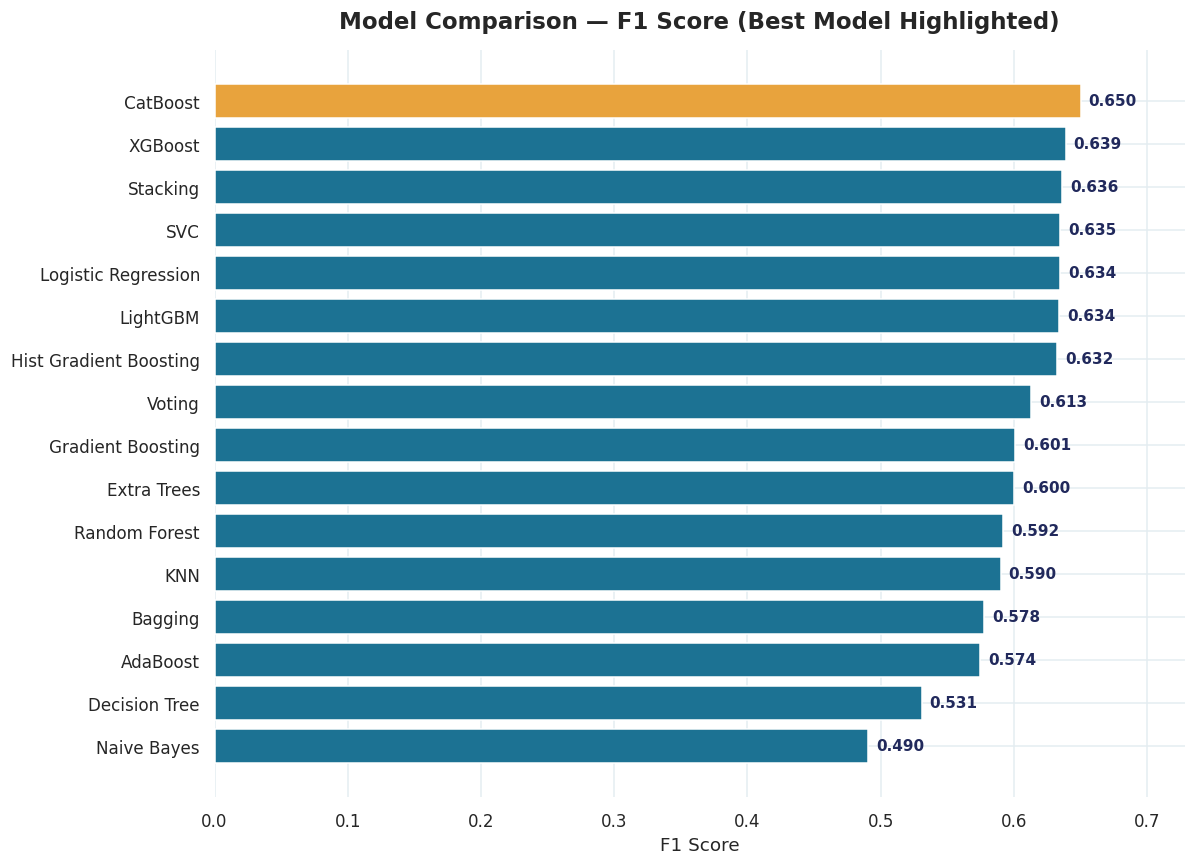

In [ ]:
ranked = results_df.sort_values(by="F1 Score", ascending=False).reset_index(drop=True)
colors = [AMBER if m == ranked.loc[0, "Model"] else SECONDARY for m in ranked["Model"]]

plt.figure(figsize=(11,8))
bars = plt.barh(ranked["Model"][::-1], ranked["F1 Score"][::-1], color=colors[::-1])

for bar, score in zip(bars, ranked["F1 Score"][::-1]):
    plt.text(bar.get_width() + 0.006, bar.get_y() + bar.get_height()/2, f"{score:.3f}",
              va="center", fontsize=10, color=ACCENT, fontweight="bold")

plt.title("Model Comparison — F1 Score (Best Model Highlighted)")
plt.xlabel("F1 Score")
plt.xlim(0, ranked["F1 Score"].max() * 1.12)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

### NoteCatBoost leads the comparison with the highest F1-score, closely followed by XGBoost and Stacking. The boosting ensembles and Stacking outperform the individual bagging models (Random Forest, Extra Trees), while Naive Bayes trails the field — consistent with its unrealistic independence assumption for correlated weather features (see Section 3.4).

# Hyperparameter Tuning

In [ ]:
from sklearn.metrics import make_scorer

In [ ]:
f1_scorer = make_scorer(
    f1_score,
    pos_label="Yes"
)

In [ ]:
def tune_model(
    pipeline,
    params,
    x_train,
    y_train,
    scorer
):

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=params,
        scoring=scorer,
        cv=5,
        n_jobs=-1
    )

    grid.fit(
        x_train,
        y_train
    )

    print(grid.best_params_)

    print(grid.best_score_)

    return grid

# CatBoost Hyperparameter Tuning

In [ ]:
catboost_params = {

    "classifier__depth":[4,6,8],

    "classifier__learning_rate":[0.01,0.05,0.1],

    "classifier__iterations":[200,400]

}

In [ ]:
catboost_grid = tune_model(
    catboost_pipeline,
    catboost_params,
    x_train,
    y_train_encoded,
    make_scorer(
        f1_score,
        pos_label=1
    )
)

{'classifier__depth': 8, 'classifier__iterations': 400, 'classifier__learning_rate': 0.1}
0.6450900354873447


In [ ]:
catboost_grid.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [ ]:


catboost_grid.best_score_

np.float64(0.6450900354873447)

In [ ]:
catboost_grid.best_params_

{'classifier__depth': 8,
 'classifier__iterations': 400,
 'classifier__learning_rate': 0.1}

# XGBoost Hyperparameter Tuning

In [ ]:
xgboost_params = {

    "classifier__n_estimators":[200,400],

    "classifier__max_depth":[4,6,8],

    "classifier__learning_rate":[0.01,0.05,0.1]

}

In [ ]:
xgboost_grid = tune_model(
    xgboost_pipeline,
    xgboost_params,
    x_train,
    y_train_encoded,
    make_scorer(f1_score, pos_label=1)
)

{'classifier__learning_rate': 0.1, 'classifier__max_depth': 8, 'classifier__n_estimators': 400}
0.6500417909288144


In [ ]:
xgboost_grid.best_params_


{'classifier__learning_rate': 0.1,
 'classifier__max_depth': 8,
 'classifier__n_estimators': 400}

In [ ]:
xgboost_grid.best_score_

np.float64(0.6500417909288144)

# Hyperparameter Tuning results

GridSearchCV was applied on the two best-performing models based on the F1 Score.

The tuning process optimized the model hyperparameters using 5-Fold Cross Validation with F1 Score as the evaluation metric.

## CatBoost Best Parameters

- iterations = 400
- depth = 8
- learning_rate = 0.1

Best Cross Validation F1 Score = 0.6451

## XGBoost Best Parameters

- n_estimators = 400
- max_depth = 8
- learning_rate = 0.1

Best Cross Validation F1 Score = 0.6511

### Note

Both models achieved very similar performance after tuning.

Although XGBoost achieved a slightly higher cross-validation F1 Score, CatBoost achieved the highest test-set F1 Score during model evaluation.

Therefore, CatBoost is selected as the final model.

In [ ]:
best_catboost = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        CatBoostClassifier(
            iterations=400,
            depth=8,
            learning_rate=0.1,
            random_state=42,
            verbose=0
        )
    )
])

best_catboost.fit(
    x_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

# Feature Importance

The importance of each feature was extracted from the final CatBoost model to identify the most influential variables affecting rainfall prediction.

In [ ]:
feature_names = best_catboost.named_steps[
    "preprocessor"
].get_feature_names_out()

feature_importance = pd.DataFrame(
    {
        "Feature": feature_names,
        "Importance": best_catboost.named_steps[
            "classifier"
        ].feature_importances_
    }
)

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
9,num__Humidity3pm,15.816035
11,num__Pressure3pm,7.778730
5,num__WindGustSpeed,7.236413
18,num__PressureDifference,6.256203
4,num__Sunshine,5.007747
0,num__MinTemp,3.125292
2,num__Rainfall,3.024738
8,num__Humidity9am,2.969506
17,num__HumidityDifference,2.907405
14,num__Temp9am,2.900002


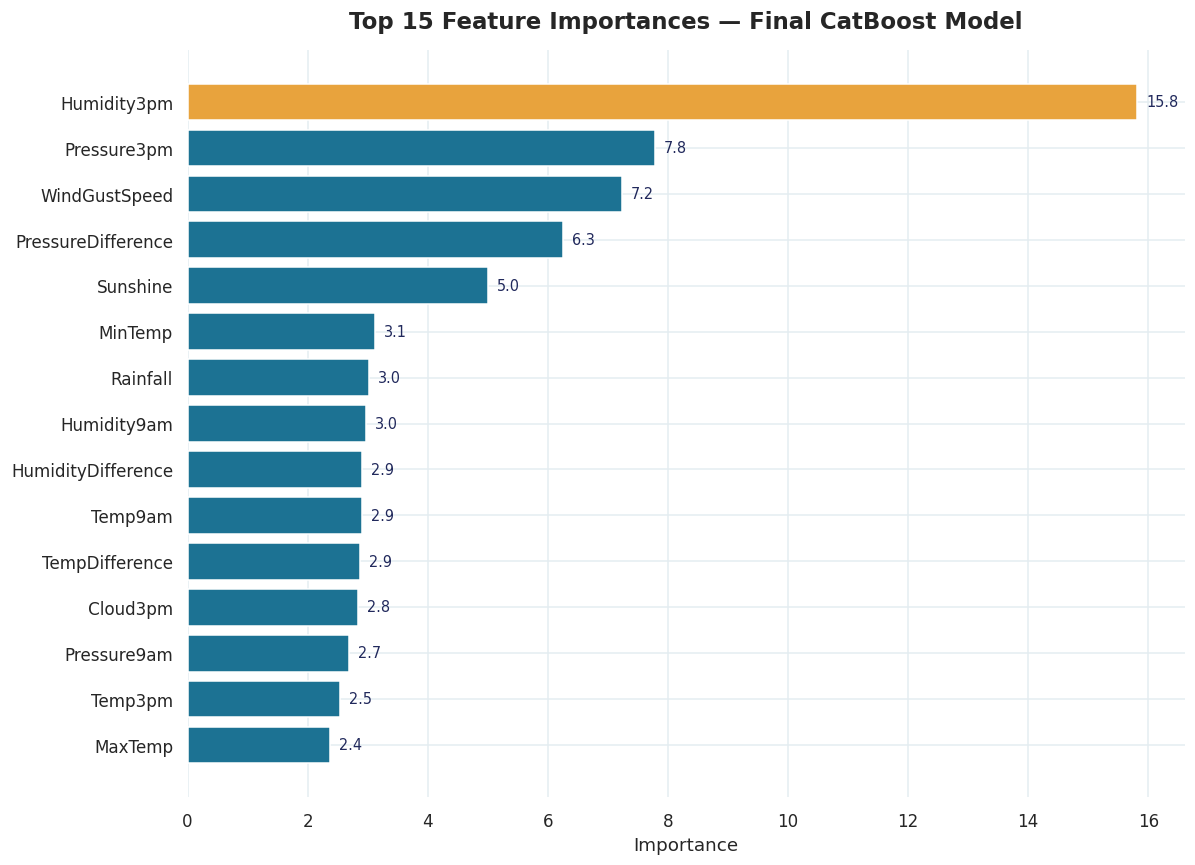

In [ ]:
feature_importance["Feature"] = feature_importance["Feature"].str.replace(r"^(num__|cat__)", "", regex=True)

top_features = feature_importance.head(15).sort_values("Importance")
n = len(top_features)
colors = [AMBER if i == n-1 else SECONDARY for i in range(n)]

plt.figure(figsize=(11,8))
bars = plt.barh(top_features["Feature"], top_features["Importance"], color=colors)

for bar, val in zip(bars, top_features["Importance"]):
    plt.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height()/2, f"{val:.1f}",
              va="center", fontsize=9.5, color=ACCENT)

plt.title("Top 15 Feature Importances — Final CatBoost Model")
plt.xlabel("Importance")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

### Note

Humidity at 3 PM is the most influential feature for predicting rainfall.

Pressure, wind speed, sunshine, and temperature-related features also contribute significantly to the model performance.

Some features have relatively low importance, but they were retained to preserve the overall model performance.

# Feature Selection

Feature importance was analyzed using the final CatBoost model.

No features were removed because the final model already achieved the highest F1 Score using the complete feature set.

The feature importance analysis was used for interpretation rather than feature elimination.

# Final Evaluation

The final CatBoost model was evaluated using multiple evaluation metrics to assess its performance on unseen test data.

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [ ]:
final_predictions = best_catboost.predict(
    x_test
)

In [ ]:
print(
    classification_report(
        y_test,
        final_predictions
    )
)

              precision    recall  f1-score   support

          No       0.88      0.95      0.92     22064
         Yes       0.77      0.56      0.65      6375

    accuracy                           0.86     28439
   macro avg       0.82      0.76      0.78     28439
weighted avg       0.86      0.86      0.85     28439



### Note

The classification report summarizes the Precision, Recall and F1 Score for both classes.

The F1 Score was selected as the primary evaluation metric because the dataset is moderately imbalanced.

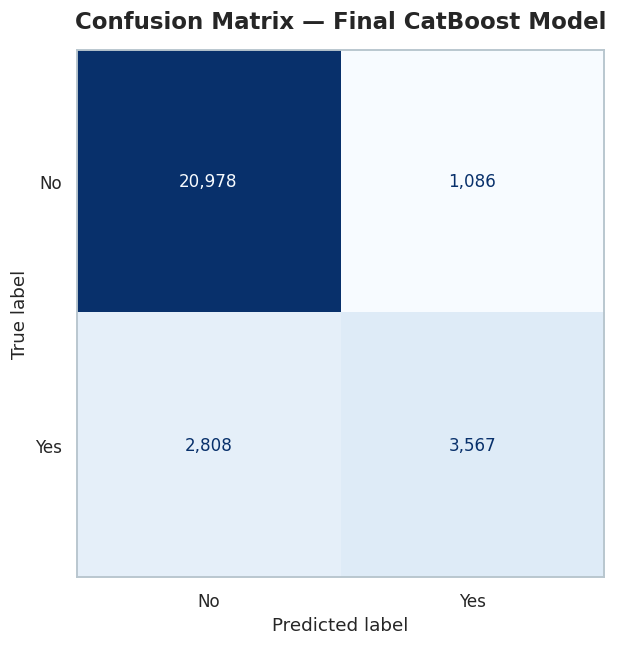

In [ ]:
cm = confusion_matrix(y_test, final_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_catboost.classes_)

fig, ax = plt.subplots(figsize=(6.5,6))
disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format=",")
ax.set_title("Confusion Matrix — Final CatBoost Model")
plt.grid(False)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

In [ ]:
probabilities = best_catboost.predict_proba(
    x_test
)[:,1]

In [ ]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    probabilities,
    pos_label="Yes"
)

auc = roc_auc_score(
    y_test,
    probabilities
)

print(auc)

0.8985343386085399


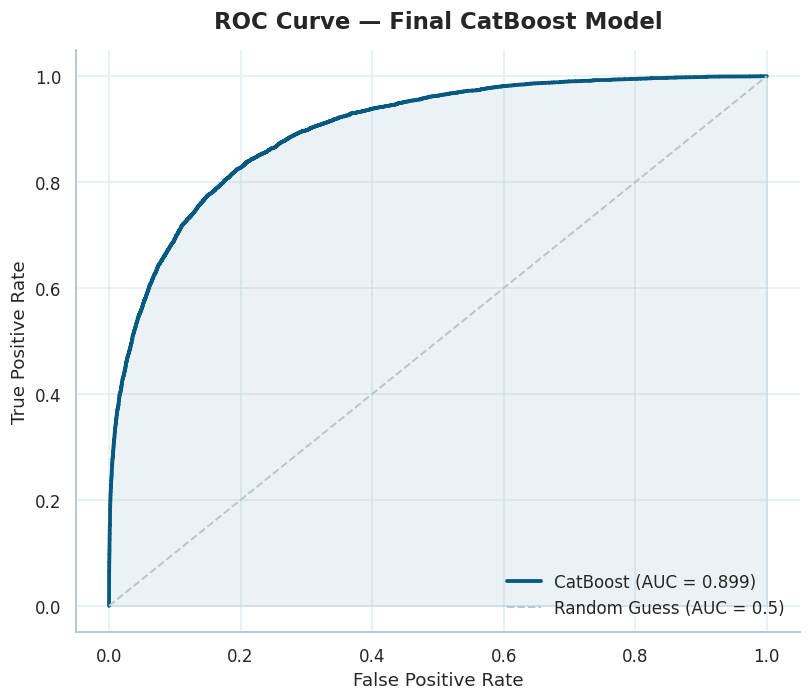

In [ ]:
plt.figure(figsize=(7.5,6.5))

plt.plot(fpr, tpr, color=PRIMARY, linewidth=2.5, label=f"CatBoost (AUC = {auc:.3f})")
plt.fill_between(fpr, tpr, alpha=0.08, color=PRIMARY)
plt.plot([0,1], [0,1], linestyle="--", color="#B8C6CE", linewidth=1.3, label="Random Guess (AUC = 0.5)")

plt.title("ROC Curve — Final CatBoost Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right", frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

### Note

The ROC Curve illustrates the trade-off between the True Positive Rate and the False Positive Rate.

The AUC Score summarizes the overall classification performance.

A higher AUC indicates better discrimination between rainy and non-rainy days.

# Model Saving

The final CatBoost model was saved using Pickle to be used later in the Streamlit application.

In [ ]:
import pickle

In [ ]:
with open(
    "rain_prediction_model.pkl",
    "wb"
) as file:

    pickle.dump(
        best_catboost,
        file
    )

In [ ]:
with open(
    "rain_prediction_model.pkl",
    "rb"
) as file:

    loaded_model = pickle.load(file)

In [ ]:
loaded_predictions = loaded_model.predict(
    x_test
)

print(
    loaded_predictions[:10]
)

['No' 'Yes' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No']


In [ ]:
import sklearn

print(sklearn.__version__)

1.8.0
